In [41]:
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from generate_data import load_model, load_saved_data, eval_accuracy

ROOT = Path('.').resolve()
CKPT = ROOT / 'models' / 'pretrain_ckpt.pt'
DATA_PKL = ROOT / '_data.pkl'

# Keep this editable for quick experiments: p_target:steps
STAGES = '0.25:100'
LR = 1e-4
WEIGHT_DECAY = 1e-3
BATCH_SIZE = 128
SEED = 107
VAL_EVERY = 1
VAL_MAX_SAMPLES = 500  # per split (other/burst). Lower = faster validation.

print('ROOT:', ROOT)
print('CKPT exists:', CKPT.exists())
print('DATA_PKL exists:', DATA_PKL.exists())

def parse_stages(stages_str):
    stages = []
    for idx, chunk in enumerate(stages_str.split(','), start=1):
        p_str, steps_str = chunk.strip().split(':')
        p_target = float(p_str)
        steps = int(steps_str)
        stages.append({'name': f'stage_{idx}', 'p_target': p_target, 'steps': steps})
    return stages


def flatten_pool(pool_dict):
    return [docs for _, docs in pool_dict.items()]


def sample_batch(target_pool_flat, bg_pool_flat, batch_size, p_target, rng):
    batch = []
    for _ in range(batch_size):
        pool = target_pool_flat if rng.random() < p_target else bg_pool_flat
        task_docs = pool[rng.integers(0, len(pool))]
        doc = task_docs[rng.integers(0, len(task_docs))]
        batch.append(doc)
    return np.stack(batch, axis=0)

ROOT: /workspace/tinystoriesFT/sunny
CKPT exists: True
DATA_PKL exists: True


Validation docs used: other=500, burst=500
step=1 stage=stage_1 loss=0.972204 train_acc=1.0000 val_other_acc=0.6347 val_burst_acc=0.1280
step=2 stage=stage_1 loss=1.266193 train_acc=0.8971 val_other_acc=0.9020 val_burst_acc=0.1837
step=3 stage=stage_1 loss=0.875755 train_acc=0.9427 val_other_acc=0.7033 val_burst_acc=0.0353
step=4 stage=stage_1 loss=0.997719 train_acc=0.8867 val_other_acc=0.8177 val_burst_acc=0.0157
step=5 stage=stage_1 loss=0.939888 train_acc=0.9674 val_other_acc=0.9373 val_burst_acc=0.0437
step=6 stage=stage_1 loss=0.870827 train_acc=0.9818 val_other_acc=0.9140 val_burst_acc=0.0697
step=7 stage=stage_1 loss=0.957603 train_acc=0.9896 val_other_acc=0.9680 val_burst_acc=0.1157
step=8 stage=stage_1 loss=0.879270 train_acc=0.9740 val_other_acc=0.9860 val_burst_acc=0.1223
step=9 stage=stage_1 loss=0.878563 train_acc=0.9818 val_other_acc=0.9590 val_burst_acc=0.1280
step=10 stage=stage_1 loss=0.897023 train_acc=0.9844 val_other_acc=0.9433 val_burst_acc=0.1673
step=11 stage=st

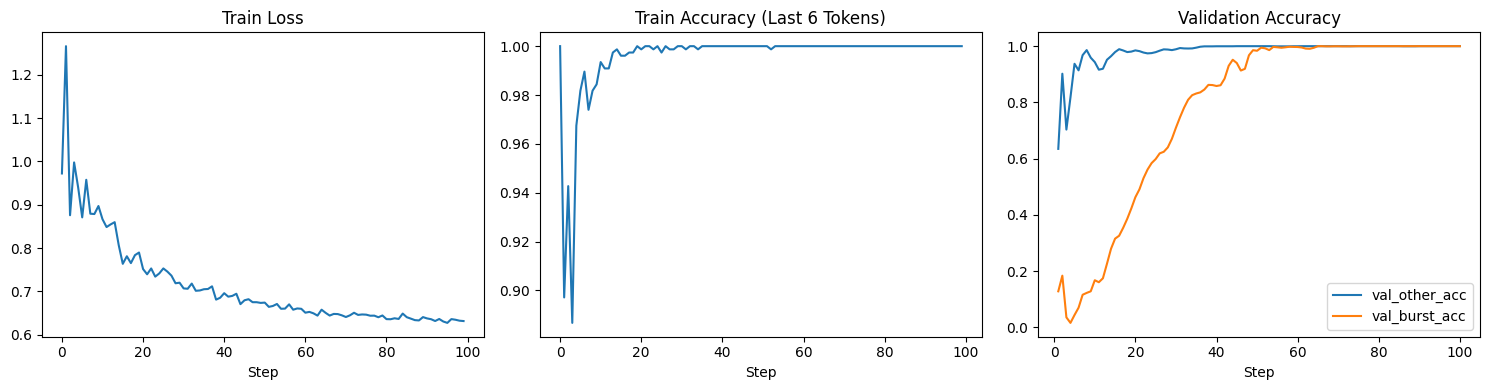

In [42]:
stages = parse_stages(STAGES)
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

data = load_saved_data(str(DATA_PKL))
target_pool = flatten_pool(data['target_pool'])
bg_pool = flatten_pool(data['bg_pool'])
eval_docs = data['eval_docs']
prompt_len = int(data['prompt_len'])

# Cap validation set size for speed
val_other_docs = eval_docs['other'][:VAL_MAX_SAMPLES]
val_burst_docs = eval_docs['burst'][:VAL_MAX_SAMPLES]
print(f"Validation docs used: other={len(val_other_docs)}, burst={len(val_burst_docs)}")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
net = load_model(str(CKPT), device=device)
net.train()
optimizer = torch.optim.AdamW(net.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

history = {'loss': [], 'train_acc': [], 'val_other_acc': [], 'val_burst_acc': [], 'global_step': []}

global_step = 0
for stage in stages:
    for stage_step in range(1, stage['steps'] + 1):
        global_step += 1

        batch_np = sample_batch(target_pool, bg_pool, BATCH_SIZE, stage['p_target'], rng)
        batch = torch.as_tensor(batch_np, dtype=torch.long, device=device)

        logits = net(batch)
        loss = F.cross_entropy(
            logits[:, :-1, :].reshape(-1, logits.size(-1)),
            batch[:, 1:].reshape(-1),
        )

        pred = logits[:, :-1, :].argmax(dim=-1)
        target = batch[:, 1:]
        ml = min(pred.shape[1], target.shape[1])
        last6 = max(0, ml - 6)
        train_acc = (pred[:, last6:ml] == target[:, last6:ml]).float().mean().item()

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        history['loss'].append(loss.item())
        history['train_acc'].append(train_acc)
        history['global_step'].append(global_step)

        do_val = (global_step % VAL_EVERY == 0)
        if do_val:
            net.eval()
            val_other_acc = eval_accuracy(net, val_other_docs, prompt_len, device=device)
            val_burst_acc = eval_accuracy(net, val_burst_docs, prompt_len, device=device)
            net.train()
            history['val_other_acc'].append(val_other_acc)
            history['val_burst_acc'].append(val_burst_acc)
            print(
                f"step={global_step} stage={stage['name']} "
                f"loss={loss.item():.6f} train_acc={train_acc:.4f} "
                f"val_other_acc={val_other_acc:.4f} val_burst_acc={val_burst_acc:.4f}"
            )
        else:
            print(f"step={global_step} stage={stage['name']} loss={loss.item():.6f} train_acc={train_acc:.4f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(history['loss'])
ax[0].set_title('Train Loss')
ax[0].set_xlabel('Step')

ax[1].plot(history['train_acc'])
ax[1].set_title('Train Accuracy (Last 6 Tokens)')
ax[1].set_xlabel('Step')

val_steps = list(range(VAL_EVERY, VAL_EVERY * len(history['val_other_acc']) + 1, VAL_EVERY))
ax[2].plot(val_steps, history['val_other_acc'], label='val_other_acc')
ax[2].plot(val_steps, history['val_burst_acc'], label='val_burst_acc')
ax[2].set_title('Validation Accuracy')
ax[2].set_xlabel('Step')
ax[2].legend()

plt.tight_layout()
plt.show()

In [44]:
# Print 10 random samples and mark whether they are from target or background.
from generate_data import DepthNData, DATA_SEED, N_A

n_show = 10
p_new = stage.get("p_target", 0.5) if isinstance(stage, dict) else 0.5

# Decoder for this synthetic dataset format
decoder = DepthNData(n_alph=10, seq_len=6, n_a=N_A, depth=3, burst_pos=1, seed=DATA_SEED)

for i in range(1, n_show + 1):
    is_new = rng.random() < p_new
    pool = target_pool if is_new else bg_pool

    task_docs = pool[rng.integers(0, len(pool))]
    sample = task_docs[rng.integers(0, len(task_docs))]

    tag = "target" if is_new else "background"
    try:
        decoded = decoder.decode(sample)
    except Exception:
        decoded = " ".join(map(str, sample.tolist()))

    print(f"[{i:02d}] {tag}: {decoded}")
    print("-" * 80)

[01] background: S F2 F3 F2   X5 X6 X5 X1 X1 X6   X6 X7 X6 X4 X4 X7   X8 X2 X8 X3 X3 X2   X5 X1 X5 X3 X3 X1
--------------------------------------------------------------------------------
[02] target: S F2 F1 F4   X3 X9 X1 X8 X0 X9   X6 X0 X1 X4 X7 X0   X9 X6 X2 X3 X1 X6   X0 X7 X1 X3 X4 X7
--------------------------------------------------------------------------------
[03] background: S F3 F3 F3   X2 X6 X5 X2 X3 X9   X0 X8 X1 X0 X7 X4   X9 X6 X5 X9 X2 X3   X4 X8 X1 X4 X0 X7
--------------------------------------------------------------------------------
[04] background: S F2 F1 F3   X2 X2 X0 X2 X3 X6   X0 X0 X9 X0 X7 X8   X6 X6 X0 X6 X1 X5   X7 X7 X8 X7 X4 X6
--------------------------------------------------------------------------------
[05] background: S F3 F3 F1   X6 X5 X9 X2 X3 X7   X9 X7 X0 X8 X4 X1   X4 X2 X9 X6 X3 X5   X3 X0 X4 X8 X7 X1
--------------------------------------------------------------------------------
[06] background: S F2 F1 F1   X5 X2 X1 X5 X4 X9   X7 X8 X2 

Now try to interp some stuff

Probe prompts: 20 (burst: 10 , normal: 10 )

=== Running CKA track for p_target=0.25 (steps=100) ===
p=0.25 step=1 loss=0.959923 cka_mean=0.8882
p=0.25 step=2 loss=1.263849 cka_mean=0.9376
p=0.25 step=3 loss=0.880546 cka_mean=0.9519
p=0.25 step=4 loss=1.001703 cka_mean=0.9529
p=0.25 step=5 loss=0.951565 cka_mean=0.9569
p=0.25 step=6 loss=0.882443 cka_mean=0.9563
p=0.25 step=7 loss=0.963749 cka_mean=0.9519
p=0.25 step=8 loss=0.887744 cka_mean=0.9369
p=0.25 step=9 loss=0.869472 cka_mean=0.9374
p=0.25 step=10 loss=0.896064 cka_mean=0.9404
p=0.25 step=11 loss=0.860426 cka_mean=0.9370
p=0.25 step=12 loss=0.851755 cka_mean=0.9305
p=0.25 step=13 loss=0.848462 cka_mean=0.9196
p=0.25 step=14 loss=0.862289 cka_mean=0.9033
p=0.25 step=15 loss=0.801843 cka_mean=0.8889
p=0.25 step=16 loss=0.763980 cka_mean=0.8832
p=0.25 step=17 loss=0.779643 cka_mean=0.8844
p=0.25 step=18 loss=0.763759 cka_mean=0.8879
p=0.25 step=19 loss=0.792482 cka_mean=0.8915
p=0.25 step=20 loss=0.786615 cka_mean=0.8956
p=0.25 s

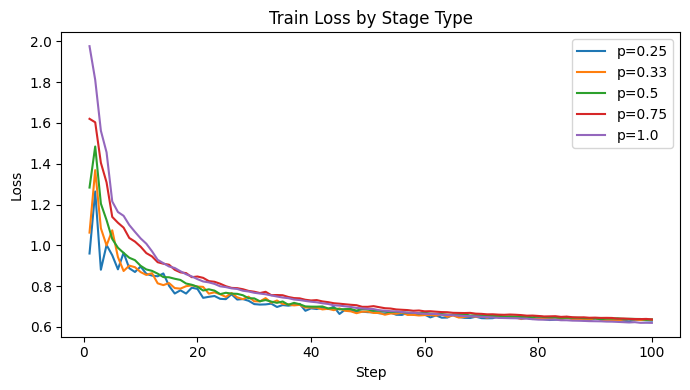

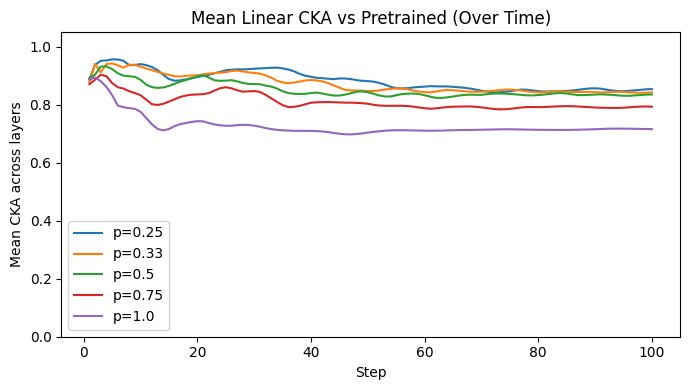

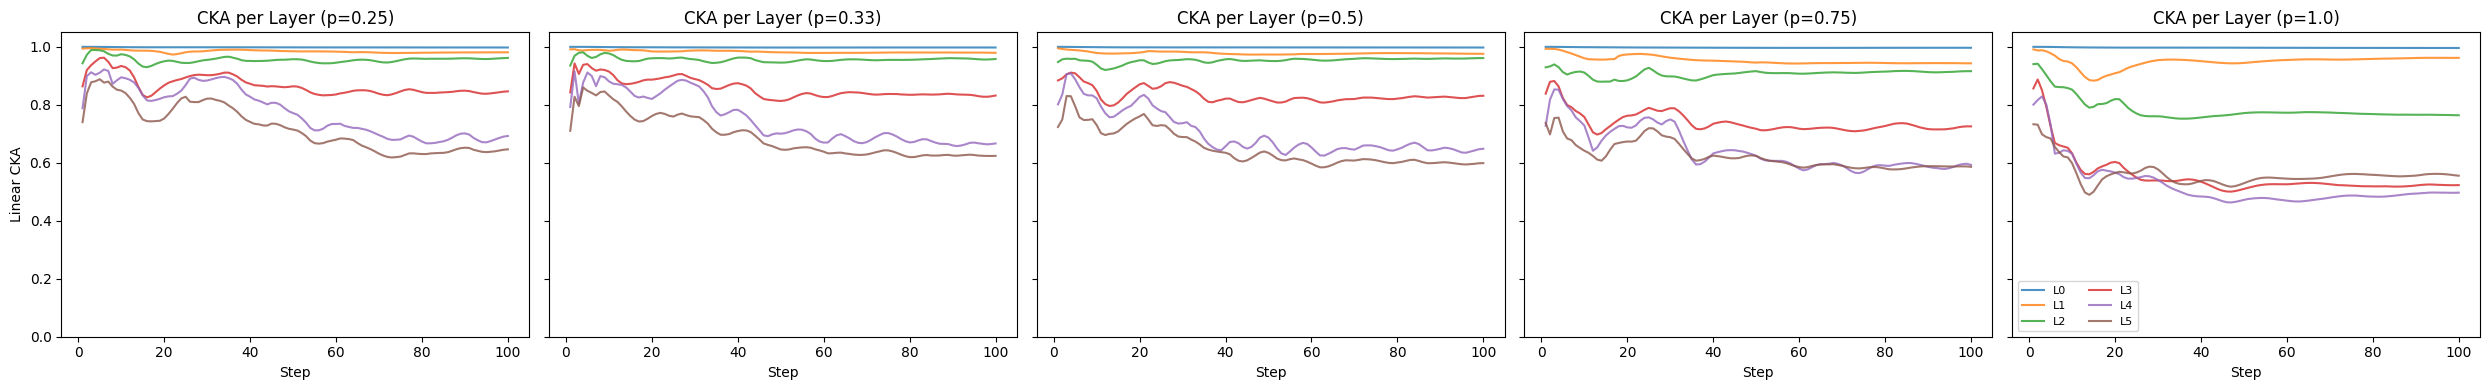

/tmp/ipykernel_89163/1398638741.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


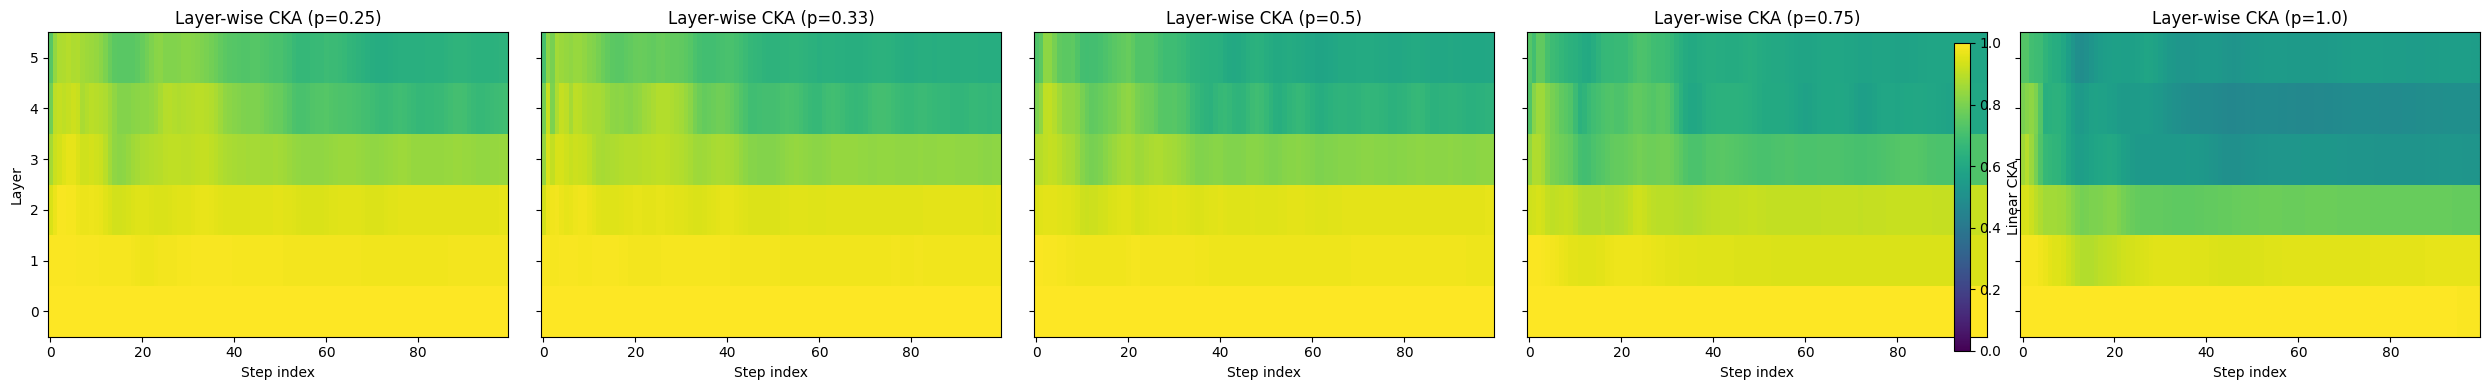

In [48]:
# Interp over time: for each stage type (0.25, 0.5, 1.0),
# compute linear CKA(layer_t, layer_0) at every training step.
from generate_data import DepthNData, DATA_SEED, N_A


def get_layer_last_token_activations(model, idx_bt):
    tok_emb = model.transformer.wte(idx_bt)
    pos = torch.arange(0, idx_bt.size(1), dtype=torch.long, device=idx_bt.device)
    pos_emb = model.transformer.wpe(pos)
    x = model.transformer.drop(tok_emb + pos_emb)

    layer_feats = []
    for block in model.transformer.h:
        x = block(x)
        layer_feats.append(x[:, -1, :].detach().cpu().numpy())  # [N, D]
    return layer_feats


def linear_cka(x, y, eps=1e-12):
    x = x - x.mean(axis=0, keepdims=True)
    y = y - y.mean(axis=0, keepdims=True)

    xty = x.T @ y
    xtx = x.T @ x
    yty = y.T @ y

    num = np.linalg.norm(xty, ord='fro') ** 2
    den = (np.linalg.norm(xtx, ord='fro') * np.linalg.norm(yty, ord='fro')) + eps
    return float(num / den)


# Use existing STAGES string only to infer steps per run
steps_per_run = parse_stages(STAGES)[0]['steps']
stage_types = [0.25, 0.33 ,0.5, 0.75, 1.0]

rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

data = load_saved_data(str(DATA_PKL))
target_pool = flatten_pool(data['target_pool'])
bg_pool = flatten_pool(data['bg_pool'])
prompt_len = int(data['prompt_len'])

# Fixed probe prompt set: 10 burst + 10 normal
decoder = DepthNData(n_alph=10, seq_len=6, n_a=N_A, depth=3, burst_pos=1, seed=DATA_SEED)
n_per_class = 10

probe_rows = []
probe_labels = []
for _ in range(n_per_class):
    task_docs = target_pool[rng.integers(0, len(target_pool))]
    sample = task_docs[rng.integers(0, len(task_docs))]
    probe_rows.append(sample[:prompt_len])
    probe_labels.append(1)
for _ in range(n_per_class):
    task_docs = bg_pool[rng.integers(0, len(bg_pool))]
    sample = task_docs[rng.integers(0, len(task_docs))]
    probe_rows.append(sample[:prompt_len])
    probe_labels.append(0)

probe_batch = torch.as_tensor(np.stack(probe_rows), dtype=torch.long, device=device)
print(
    "Probe prompts:", probe_batch.shape[0],
    "(burst:", int(np.sum(probe_labels)),
    ", normal:", int(len(probe_labels) - np.sum(probe_labels)), ")"
)

# Reference pretrained model (frozen)
ref_net = load_model(str(CKPT), device=device)
ref_net.eval()
with torch.no_grad():
    ref_feats = get_layer_last_token_activations(ref_net, probe_batch)

n_layers = len(ref_feats)
results = {}

for p_target in stage_types:
    print(f"\n=== Running CKA track for p_target={p_target} (steps={steps_per_run}) ===")

    # fresh trainable model per stage type
    net = load_model(str(CKPT), device=device)
    net.train()
    optimizer = torch.optim.AdamW(net.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    cka_history = [[] for _ in range(n_layers)]
    loss_history = []
    step_history = []

    for step in range(1, steps_per_run + 1):
        batch_np = sample_batch(target_pool, bg_pool, BATCH_SIZE, p_target, rng)
        batch = torch.as_tensor(batch_np, dtype=torch.long, device=device)

        logits = net(batch)
        loss = F.cross_entropy(
            logits[:, :-1, :].reshape(-1, logits.size(-1)),
            batch[:, 1:].reshape(-1),
        )

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        net.eval()
        with torch.no_grad():
            cur_feats = get_layer_last_token_activations(net, probe_batch)
        net.train()

        ckas = [linear_cka(cur_feats[layer_idx], ref_feats[layer_idx]) for layer_idx in range(n_layers)]
        for layer_idx, cka_val in enumerate(ckas):
            cka_history[layer_idx].append(cka_val)

        loss_history.append(float(loss.item()))
        step_history.append(step)

        print(f"p={p_target} step={step} loss={loss.item():.6f} cka_mean={np.mean(ckas):.4f}")

    results[p_target] = {
        'steps': step_history,
        'loss': loss_history,
        'cka_history': cka_history,
        'cka_matrix': np.array(cka_history),
    }

# Plot: loss over time by stage type
plt.figure(figsize=(7, 4))
for p_target in stage_types:
    plt.plot(results[p_target]['steps'], results[p_target]['loss'], label=f'p={p_target}')
plt.title('Train Loss by Stage Type')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Plot: mean CKA over layers by stage type
plt.figure(figsize=(7, 4))
for p_target in stage_types:
    mean_cka = results[p_target]['cka_matrix'].mean(axis=0)
    plt.plot(results[p_target]['steps'], mean_cka, label=f'p={p_target}')
plt.title('Mean Linear CKA vs Pretrained (Over Time)')
plt.xlabel('Step')
plt.ylabel('Mean CKA across layers')
plt.ylim(0.0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

# Plot: per-layer CKA curves for each stage type
fig, axes = plt.subplots(1, len(stage_types), figsize=(5 * len(stage_types), 4), sharey=True)
if len(stage_types) == 1:
    axes = [axes]
for ax, p_target in zip(axes, stage_types):
    for layer_idx in range(n_layers):
        ax.plot(results[p_target]['steps'], results[p_target]['cka_history'][layer_idx], alpha=0.8, label=f'L{layer_idx}')
    ax.set_title(f'CKA per Layer (p={p_target})')
    ax.set_xlabel('Step')
    ax.set_ylim(0.0, 1.05)
axes[0].set_ylabel('Linear CKA')
axes[-1].legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

# Optional: heatmaps (layer x step) for each stage type
fig, axes = plt.subplots(1, len(stage_types), figsize=(5 * len(stage_types), 4), sharey=True)
if len(stage_types) == 1:
    axes = [axes]
for ax, p_target in zip(axes, stage_types):
    im = ax.imshow(results[p_target]['cka_matrix'], aspect='auto', origin='lower', interpolation='nearest', vmin=0.0, vmax=1.0)
    ax.set_title(f'Layer-wise CKA (p={p_target})')
    ax.set_xlabel('Step index')
axes[0].set_ylabel('Layer')
fig.colorbar(im, ax=axes, label='Linear CKA')
plt.tight_layout()
plt.show()

In [49]:
net

nanoGPT(
  (transformer): ModuleDict(
    (wte): Embedding(128, 120)
    (wpe): Embedding(80, 120)
    (drop): Dropout(p=0.0, inplace=False)
    (h): ModuleList(
      (0-5): 6 x Block(
        (ln_1): LayerNorm()
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=120, out_features=360, bias=False)
          (c_proj): Linear(in_features=120, out_features=120, bias=False)
          (attn_dropout): Dropout(p=0.0, inplace=False)
          (resid_dropout): Dropout(p=0.0, inplace=False)
        )
        (ln_2): LayerNorm()
        (mlp): MLP(
          (c_fc): Linear(in_features=120, out_features=480, bias=False)
          (gelu): GELU(approximate='none')
          (c_proj): Linear(in_features=480, out_features=120, bias=False)
          (dropout): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm()
  )
  (LM_head): Linear(in_features=120, out_features=128, bias=False)
)

In [50]:
# Inspect current `net` architecture in finetune_by_step.ipynb
import torch

def count_params(module):
    all_p = sum(p.numel() for p in module.parameters())
    train_p = sum(p.numel() for p in module.parameters() if p.requires_grad)
    return all_p, train_p

if "net" not in globals():
    # Fallback: load pretrained checkpoint if net isn't in memory
    from generate_data import load_model
    net = load_model(str(CKPT), device=("cuda" if torch.cuda.is_available() else "cpu"))

cfg = getattr(net, "config", None)
print("=== Net Summary ===")
print("Model class:", net.__class__.__name__)

if cfg is not None:
    n_layer = int(getattr(cfg, "n_layer", -1))
    n_head = int(getattr(cfg, "n_head", -1))
    n_embd = int(getattr(cfg, "n_embd", -1))
    context_size = int(getattr(cfg, "context_size", -1))
    vocab_size = int(getattr(cfg, "vocab_size", -1))
    dropout = float(getattr(cfg, "dropout", float("nan")))
    bias = bool(getattr(cfg, "bias", False))
    mlp_on = bool(getattr(cfg, "mlp", True))

    head_dim = n_embd // n_head if n_head > 0 else None

    print("n_layer:", n_layer)
    print("n_head:", n_head)
    print("n_embd:", n_embd)
    print("head_dim:", head_dim)
    print("context_size:", context_size)
    print("vocab_size:", vocab_size)
    print("dropout:", dropout)
    print("bias:", bias)
    print("mlp:", mlp_on)
else:
    print("No net.config found")

all_params, trainable_params = count_params(net)
print("\n=== Parameter Counts ===")
print(f"Total params:     {all_params:,}")
print(f"Trainable params: {trainable_params:,}")

print("\n=== Per-block Attention Check ===")
for i, block in enumerate(net.transformer.h):
    attn = block.attn
    print(
        f"Block {i}: n_head={attn.n_head}, "
        f"attn_in={attn.c_attn.in_features}, attn_out={attn.c_attn.out_features}, "
        f"proj={attn.c_proj.in_features}->{attn.c_proj.out_features}"
    )

=== Net Summary ===
Model class: nanoGPT
n_layer: 6
n_head: 4
n_embd: 120
head_dim: 30
context_size: 80
vocab_size: 128
dropout: 0.0
bias: False
mlp: True

=== Parameter Counts ===
Total params:     1,063,320
Trainable params: 1,063,320

=== Per-block Attention Check ===
Block 0: n_head=4, attn_in=120, attn_out=360, proj=120->120
Block 1: n_head=4, attn_in=120, attn_out=360, proj=120->120
Block 2: n_head=4, attn_in=120, attn_out=360, proj=120->120
Block 3: n_head=4, attn_in=120, attn_out=360, proj=120->120
Block 4: n_head=4, attn_in=120, attn_out=360, proj=120->120
Block 5: n_head=4, attn_in=120, attn_out=360, proj=120->120


/tmp/ipykernel_89163/1639524798.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


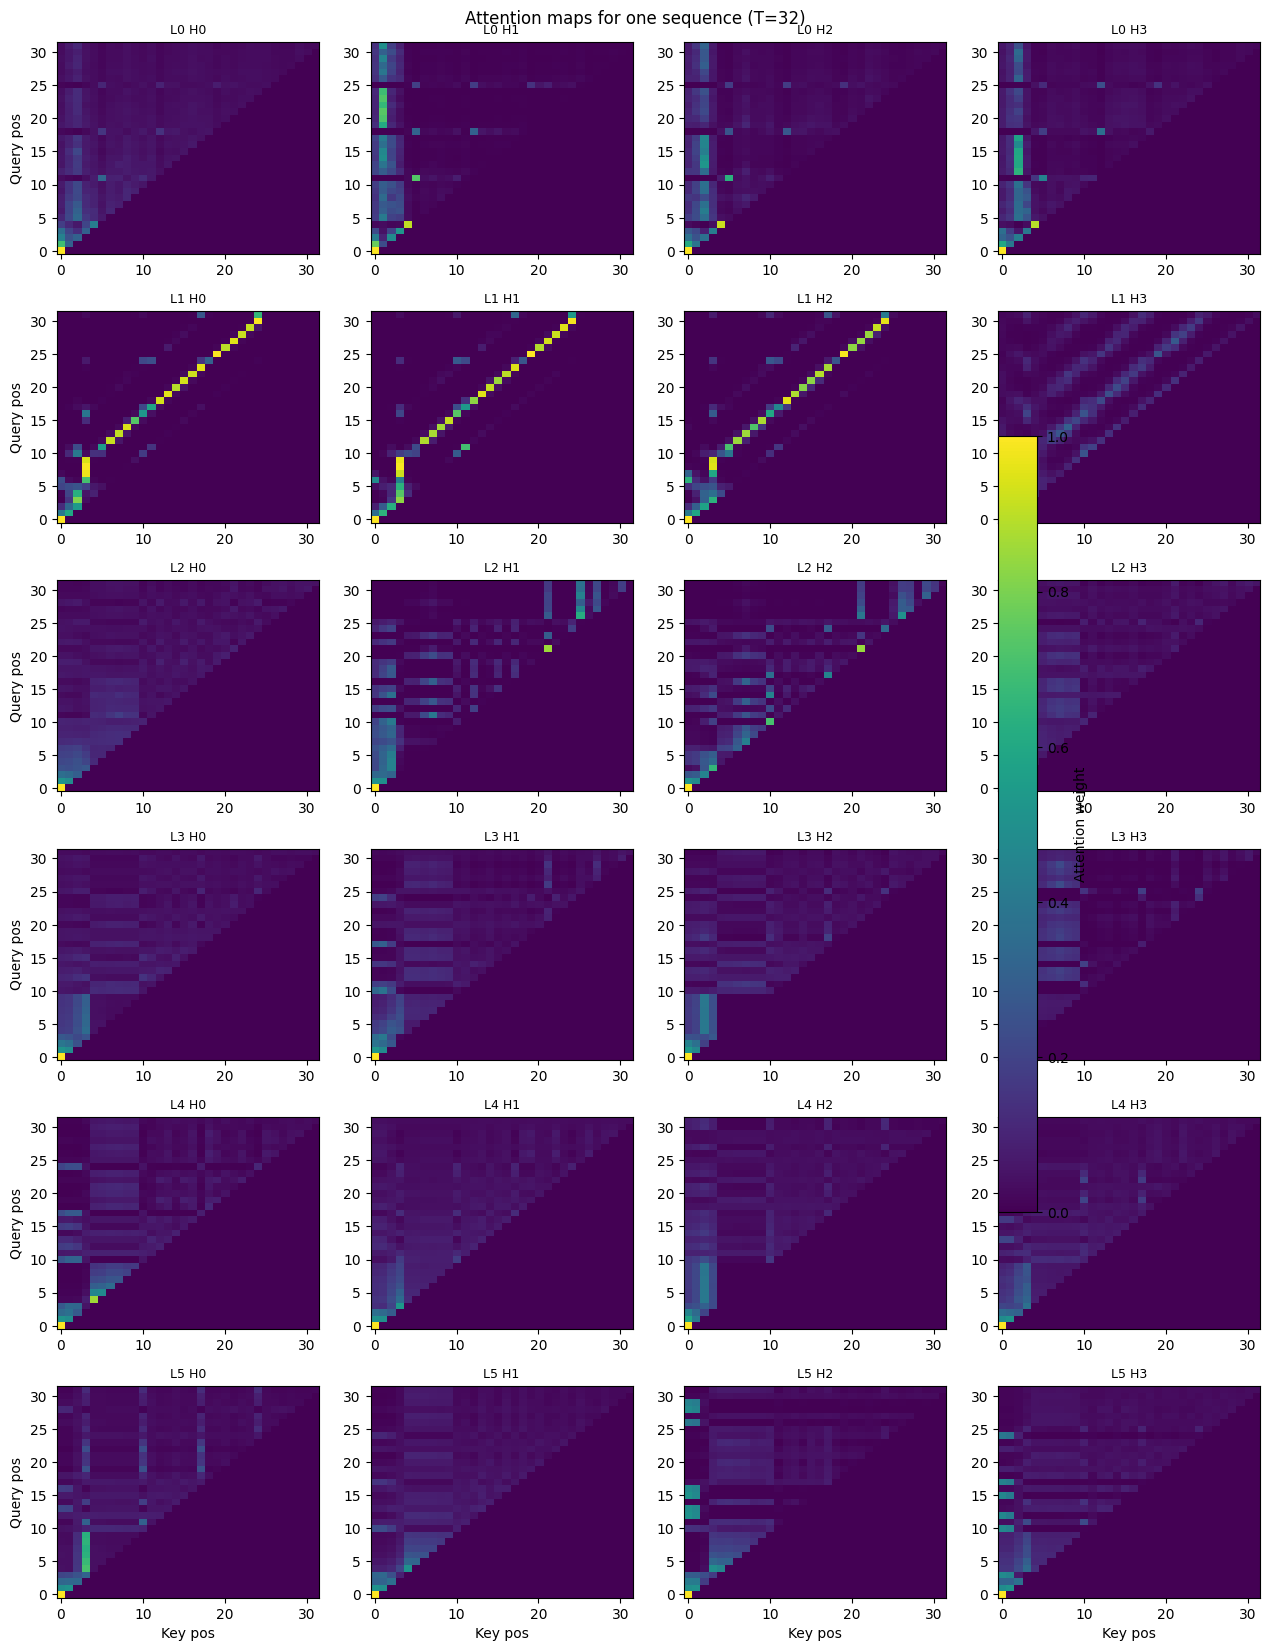

In [52]:
# Plot all attention heads for each layer on one sample sequence
import math
import numpy as np
import matplotlib.pyplot as plt
import torch


def get_attention_maps_all_layers(model, idx_bt):
    """Return list of attention maps per layer: [n_layer] each [B, n_head, T, T]."""
    model.eval()
    maps = []
    with torch.no_grad():
        x = model.transformer.wte(idx_bt)
        pos = torch.arange(0, idx_bt.size(1), dtype=torch.long, device=idx_bt.device)
        x = model.transformer.drop(x + model.transformer.wpe(pos))

        for block in model.transformer.h:
            h = block.ln_1(x)
            B, T, C = h.shape
            n_head = block.attn.n_head
            head_dim = C // n_head

            qkv = block.attn.c_attn(h)
            q, k, v = qkv.split(C, dim=2)

            q = q.view(B, T, n_head, head_dim).transpose(1, 2)  # [B, H, T, D]
            k = k.view(B, T, n_head, head_dim).transpose(1, 2)  # [B, H, T, D]
            v = v.view(B, T, n_head, head_dim).transpose(1, 2)  # [B, H, T, D]

            scores = (q @ k.transpose(-2, -1)) / math.sqrt(head_dim)  # [B, H, T, T]
            causal_mask = torch.triu(torch.ones(T, T, device=h.device, dtype=torch.bool), diagonal=1)
            scores = scores.masked_fill(causal_mask, float("-inf"))
            att = torch.softmax(scores, dim=-1)
            maps.append(att.detach().cpu())

            y = att @ v
            y = y.transpose(1, 2).contiguous().view(B, T, C)
            y = block.attn.resid_dropout(block.attn.c_proj(y))
            x = x + y
            if hasattr(block, "mlp"):
                x = x + block.mlp(block.ln_2(x))
    return maps


# Choose an example sequence from burst validation docs
if "val_burst_docs" in globals() and len(val_burst_docs) > 0:
    seq = val_burst_docs[0]
elif "eval_docs" in globals() and "burst" in eval_docs and len(eval_docs["burst"]) > 0:
    seq = eval_docs["burst"][0]
else:
    raise RuntimeError("No burst validation docs found. Run earlier data-loading cells first.")

seq = np.asarray(seq, dtype=np.int64)
if "context_size" in globals():
    seq = seq[:context_size]

input_ids = torch.as_tensor(seq[None, :], dtype=torch.long, device=device)
attn_maps = get_attention_maps_all_layers(net, input_ids)

n_layer = len(attn_maps)
n_head = attn_maps[0].shape[1]
T = attn_maps[0].shape[-1]

fig, axes = plt.subplots(n_layer, n_head, figsize=(3.2 * n_head, 2.8 * n_layer), squeeze=False)
for l in range(n_layer):
    for h in range(n_head):
        ax = axes[l, h]
        m = attn_maps[l][0, h].numpy()  # [T, T]
        im = ax.imshow(m, origin="lower", aspect="auto", vmin=0.0, vmax=1.0, cmap="viridis")
        ax.set_title(f"L{l} H{h}", fontsize=9)
        if l == n_layer - 1:
            ax.set_xlabel("Key pos")
        if h == 0:
            ax.set_ylabel("Query pos")

fig.suptitle(f"Attention maps for one sequence (T={T})", fontsize=12)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label="Attention weight")
plt.tight_layout()
plt.show()

/venv/main/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9248 (\N{SYMBOL FOR SPACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


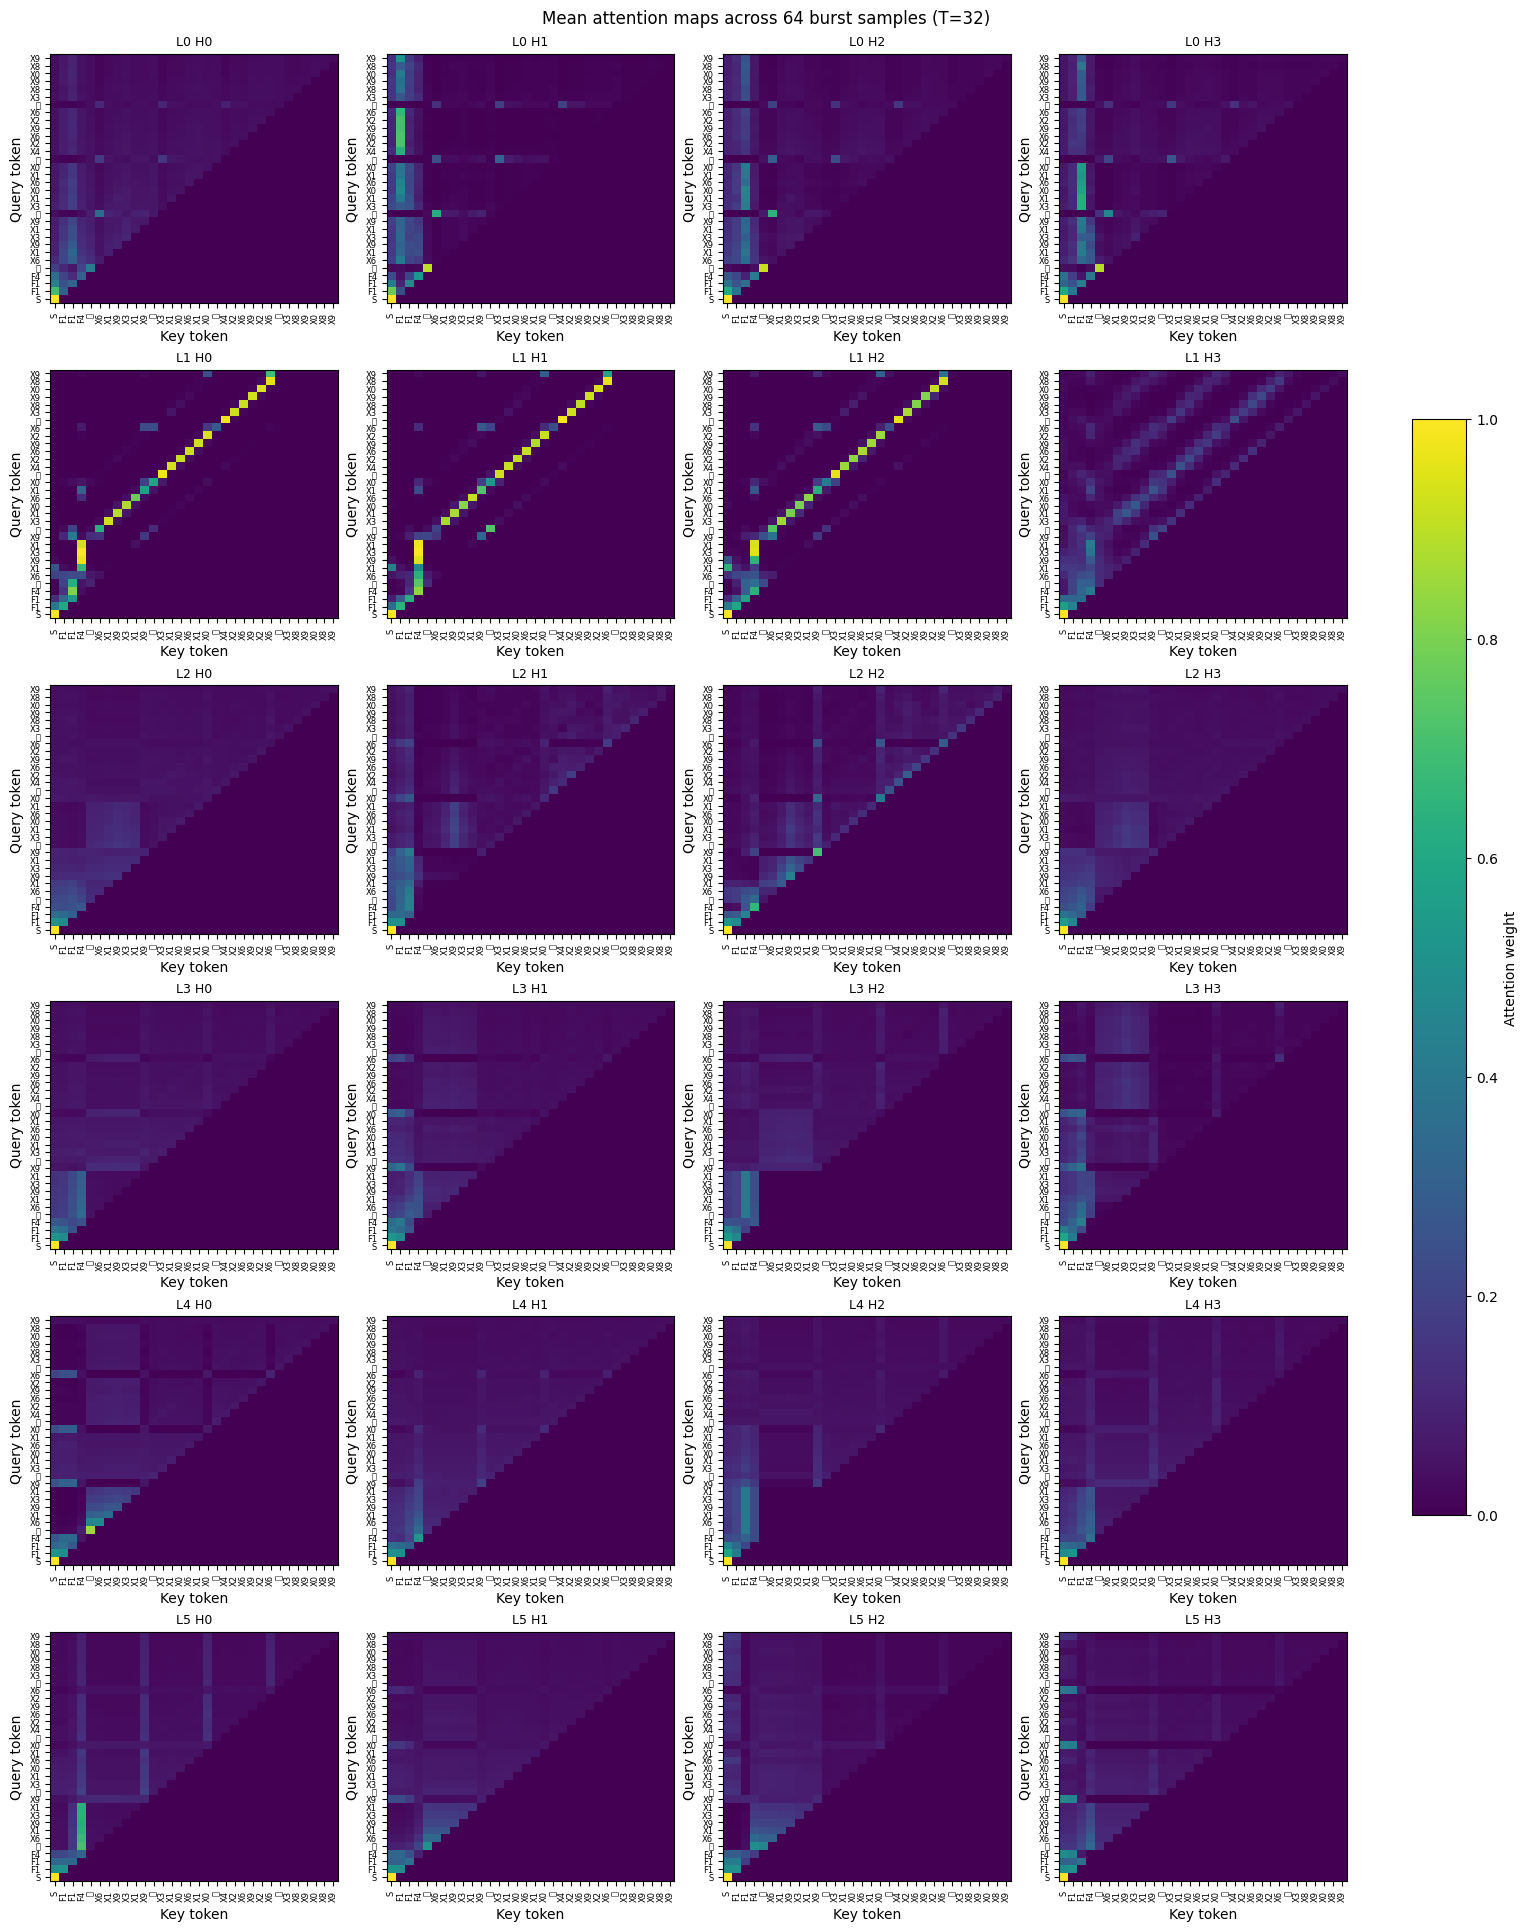

In [54]:
# Average attention maps across many samples, and label x/y ticks with token names on every subplot
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
from generate_data import DepthNData, DATA_SEED, N_A


def get_attention_maps_all_layers(model, idx_bt):
    """Return attention maps per layer: list of [B, H, T, T]."""
    model.eval()
    maps = []
    with torch.no_grad():
        x = model.transformer.wte(idx_bt)
        pos = torch.arange(0, idx_bt.size(1), dtype=torch.long, device=idx_bt.device)
        x = model.transformer.drop(x + model.transformer.wpe(pos))

        for block in model.transformer.h:
            h = block.ln_1(x)
            B, T, C = h.shape
            n_head = block.attn.n_head
            head_dim = C // n_head

            qkv = block.attn.c_attn(h)
            q, k, v = qkv.split(C, dim=2)

            q = q.view(B, T, n_head, head_dim).transpose(1, 2)
            k = k.view(B, T, n_head, head_dim).transpose(1, 2)
            v = v.view(B, T, n_head, head_dim).transpose(1, 2)

            scores = (q @ k.transpose(-2, -1)) / math.sqrt(head_dim)
            causal_mask = torch.triu(torch.ones(T, T, device=h.device, dtype=torch.bool), diagonal=1)
            scores = scores.masked_fill(causal_mask, float("-inf"))
            att = torch.softmax(scores, dim=-1)
            maps.append(att.detach().cpu())

            y = att @ v
            y = y.transpose(1, 2).contiguous().view(B, T, C)
            y = block.attn.resid_dropout(block.attn.c_proj(y))
            x = x + y
            if hasattr(block, "mlp"):
                x = x + block.mlp(block.ln_2(x))
    return maps


# --- Build a batch of samples to average over ---
N_SAMPLES = 64
if "val_burst_docs" in globals() and len(val_burst_docs) > 0:
    docs = val_burst_docs
elif "eval_docs" in globals() and "burst" in eval_docs and len(eval_docs["burst"]) > 0:
    docs = eval_docs["burst"]
else:
    raise RuntimeError("No burst docs available. Run the data-loading/training cells first.")

n_take = min(N_SAMPLES, len(docs))
rows = np.asarray(docs[:n_take], dtype=np.int64)

if "context_size" in globals():
    rows = rows[:, :context_size]

input_ids = torch.as_tensor(rows, dtype=torch.long, device=device)
attn_maps = get_attention_maps_all_layers(net, input_ids)

# Mean over batch -> [H, T, T] per layer
mean_maps = [m.mean(dim=0).numpy() for m in attn_maps]
n_layer = len(mean_maps)
n_head = mean_maps[0].shape[0]
T = mean_maps[0].shape[-1]


# --- Token labels for ticks ---
if "decoder" not in globals():
    decoder = DepthNData(n_alph=10, seq_len=6, n_a=N_A, depth=3, burst_pos=1, seed=DATA_SEED)

token_ids = rows[0, :T].tolist()
token_labels = [decoder.token.get(int(tid), str(int(tid))) for tid in token_ids]
token_labels = ["␠" if tok == " " else tok for tok in token_labels]

fig, axes = plt.subplots(
    n_layer, n_head,
    figsize=(3.8 * n_head, 3.2 * n_layer),
    squeeze=False,
    constrained_layout=True,
    sharex=True,
    sharey=True,
 )

xticks = np.arange(T)
yticks = np.arange(T)

for l in range(n_layer):
    for h in range(n_head):
        ax = axes[l, h]
        m = mean_maps[l][h]  # [T, T]
        im = ax.imshow(m, origin="lower", aspect="auto", vmin=0.0, vmax=1.0, cmap="viridis")
        ax.set_title(f"L{l} H{h}", fontsize=9)

        # Show identical x/y tick positions + labels on every subplot
        ax.set_xticks(xticks)
        ax.set_xticklabels(token_labels, rotation=90, fontsize=6)
        ax.set_yticks(yticks)
        ax.set_yticklabels(token_labels, fontsize=6)
        ax.tick_params(axis="x", labelbottom=True)
        ax.tick_params(axis="y", labelleft=True)

        ax.set_xlabel("Key token")
        ax.set_ylabel("Query token")

fig.suptitle(f"Mean attention maps across {n_take} burst samples (T={T})", fontsize=12)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label="Attention weight")
plt.show()